## Loan Approval & Credit Risk Intelligent System

### Objective: Predicting the probability of a borrower default risk using LendingClub data with explainable machine learning. 

### Deliverables:
- Default probability prediction
- Risk Categorization
- Explainable AI using SHAP
- Deployment ready ML Pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve
from xgboost import XGBClassifier
import shap
import joblib

In [2]:
pd.set_option('display.max_rows', None)

In [3]:
df=pd.read_csv("../data.csv", low_memory=False)
df.shape

(2260701, 151)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [5]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [7]:
valid_status=["Fully Paid","Charged Off"]
df=df[df["loan_status"].isin(valid_status)].copy()
df['target']=df['loan_status'].map({'Fully Paid':0, 'Charged Off':1})
df['target'].value_counts(normalize=True)

target
0    0.800374
1    0.199626
Name: proportion, dtype: float64

### Removing:
- Identifiers
- Leakage Variables
- Settlement Variables (Post default -> Leakage)
- Hardship Variables (Reflect borrower distress -> Almost default)
- Extremely Sparse Features (Removed if missingness did not carry meaningful information)

In [8]:
features= ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal',
       'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
       'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
       'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats',
       'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
       'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
       'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim',
       'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
       'disbursement_method']
X=df[features]
Y=df['target']

In [9]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=25,stratify=Y)

In [16]:
cat_cols=['term','grade','sub_grade','emp_length','home_ownership', 'verification_status', 'purpose',
          'application_type', 'disbursement_method']
num_cols=[col for col in X.columns if col not in cat_cols]
num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocess=ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [29]:
log_model=Pipeline([
    ("preprocess", preprocess),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
log_model.fit(X_train,Y_train)
log_prob=log_model.predict_proba(X_test)[:,1]
log_pred=log_prob>=0.5
print(roc_auc_score(Y_test,log_prob))
print(classification_report(Y_test,log_pred))

0.7150767910673779
              precision    recall  f1-score   support

           0       0.89      0.64      0.74    215350
           1       0.32      0.67      0.43     53712

    accuracy                           0.65    269062
   macro avg       0.60      0.66      0.59    269062
weighted avg       0.77      0.65      0.68    269062



In [35]:
rf_model=Pipeline([
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=25, n_jobs=-1, max_depth=5))
])
rf_model.fit(X_train,Y_train)
rf_prob=rf_model.predict_proba(X_test)[:,1]
rf_features = rf_model.named_steps["preprocess"].get_feature_names_out()
rf_importance = rf_model.named_steps["classifier"].feature_importances_
rf_importance_df = pd.DataFrame({"feature": rf_features,"importance": rf_importance}).sort_values(
    "importance",ascending=False)
print(roc_auc_score(Y_test,rf_prob))
print(rf_importance_df.head(25))

0.7054741322966354
                                   feature  importance
1                            num__int_rate    0.185770
55                    cat__term_ 36 months    0.128551
56                    cat__term_ 60 months    0.110054
57                            cat__grade_A    0.082968
61                            cat__grade_E    0.051796
58                            cat__grade_B    0.047781
6                      num__fico_range_low    0.044285
7                     num__fico_range_high    0.031183
4                                 num__dti    0.028795
60                            cat__grade_D    0.027485
20               num__acc_open_past_24mths    0.020239
62                            cat__grade_F    0.019989
64                       cat__sub_grade_A1    0.016315
51                    num__tot_hi_cred_lim    0.014534
21                        num__avg_cur_bal    0.014337
30                           num__mort_acc    0.013986
116  cat__verification_status_Not Verified    

In [36]:
xgb_model=Pipeline([
    ("preprocess", preprocess),
    ("classifier", XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=31,
                                 eval_metric="logloss", subsample=0.75, colsample_bytree=0.75))
])
xgb_model.fit(X_train,Y_train)
xgb_prob=xgb_model.predict_proba(X_test)[:,1]
xgb_features = xgb_model.named_steps["preprocess"].get_feature_names_out()
xgb_importance = xgb_model.named_steps["classifier"].feature_importances_
xgb_importance_df = pd.DataFrame({"feature": xgb_features,"importance": xgb_importance}).sort_values(
    "importance",ascending=False)
print(roc_auc_score(Y_test,xgb_prob))
print(xgb_importance_df.head(25))

0.7242297861120569
                                   feature  importance
57                            cat__grade_A    0.216898
1                            num__int_rate    0.100671
58                            cat__grade_B    0.085128
59                            cat__grade_C    0.068499
60                            cat__grade_D    0.046522
56                    cat__term_ 60 months    0.033514
55                    cat__term_ 36 months    0.031230
61                            cat__grade_E    0.020919
30                           num__mort_acc    0.015423
72                       cat__sub_grade_B4    0.014210
73                       cat__sub_grade_B5    0.013988
116  cat__verification_status_Not Verified    0.013838
6                      num__fico_range_low    0.013268
75                       cat__sub_grade_C2    0.012924
74                       cat__sub_grade_C1    0.012451
4                                 num__dti    0.012122
115               cat__home_ownership_RENT    

In [37]:
scores=cross_val_score(xgb_model, X_train,Y_train,
                       cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=16),
                       scoring="roc_auc", n_jobs=-1)
print(scores)
print(scores.mean())

[0.72684495 0.72326531 0.72442434 0.72532922 0.72508006]
0.7249887765190729


In [40]:
params={
    "classifier__n_estimators": [100,200,300,500],
    "classifier__max_depth": [3,4,5,6,7],
    "classifier__learning_rate": [0.05,0.1,0.2],
    "classifier__subsample": [0.6,0.7,0.8],
    "classifier__colsample_bytree": [0.6,0.7,0.8],
    "classifier__min_child_weight": [1,3,5]
}
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=params,
    n_iter=30,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3,shuffle=True),
    verbose=3,
    random_state=5,
    n_jobs=-1
)
search.fit(X_train, Y_train)
print(search.best_score_)
print(search.best_params_)
best_xgb=search.best_estimator_
best_prob=best_xgb.predict_proba(X_test)[:,1]
print(roc_auc_score(Y_test,best_prob))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
0.7317177337869448
{'classifier__subsample': 0.8, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
0.7316925985965169


In [41]:
for threshold in [0.3,0.4,0.5,0.6,0.7]:
    pred=best_prob>threshold
    print(threshold)
    print(classification_report(Y_test,pred))

0.3
              precision    recall  f1-score   support

           0       0.86      0.85      0.85    215350
           1       0.41      0.42      0.42     53712

    accuracy                           0.77    269062
   macro avg       0.63      0.64      0.64    269062
weighted avg       0.77      0.77      0.77    269062

0.4
              precision    recall  f1-score   support

           0       0.83      0.94      0.88    215350
           1       0.50      0.23      0.31     53712

    accuracy                           0.80    269062
   macro avg       0.66      0.59      0.60    269062
weighted avg       0.76      0.80      0.77    269062

0.5
              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215350
           1       0.58      0.10      0.18     53712

    accuracy                           0.81    269062
   macro avg       0.70      0.54      0.53    269062
weighted avg       0.77      0.81      0.75    269062

0.6
   

In [53]:
importance_df=pd.DataFrame({
    "Feature": best_xgb.named_steps["preprocess"].get_feature_names_out(),
    "Importance":best_xgb.named_steps["classifier"].feature_importances_
})
importance_df=importance_df.sort_values("Importance", ascending=False)
print(importance_df.head(25))

                                   Feature  Importance
57                            cat__grade_A    0.279198
58                            cat__grade_B    0.085969
1                            num__int_rate    0.047408
56                    cat__term_ 60 months    0.046825
55                    cat__term_ 36 months    0.035253
59                            cat__grade_C    0.030358
60                            cat__grade_D    0.020287
64                       cat__sub_grade_A1    0.016477
111           cat__home_ownership_MORTGAGE    0.011870
115               cat__home_ownership_RENT    0.011628
73                       cat__sub_grade_B5    0.011070
30                           num__mort_acc    0.010519
61                            cat__grade_E    0.009743
68                       cat__sub_grade_A5    0.009432
116  cat__verification_status_Not Verified    0.008928
74                       cat__sub_grade_C1    0.008912
20               num__acc_open_past_24mths    0.007591
6         

In [11]:
X_train_modif=X_train.drop(columns=['grade','sub_grade','int_rate'], axis='columns')
X_test_modif=X_test.drop(columns=['grade','sub_grade', 'int_rate'], axis='columns')
num_cols_modif = [c for c in num_cols if c not in ['int_rate']]
cat_cols_modif = [c for c in cat_cols if c not in ['grade', 'sub_grade']]
preprocess_modif = ColumnTransformer([
    ("num",Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
    ]),num_cols_modif),
    ("cat",Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),cat_cols_modif)
])
modif_model = Pipeline([
    ("preprocess", preprocess_modif),
    ("classifier",XGBClassifier(n_estimators=500,learning_rate=0.05,max_depth=7,random_state=31,
                                eval_metric="logloss",subsample=0.8,colsample_bytree=0.7,min_child_weight=1
     ))
])
modif_model.fit(X_train_modif,Y_train)
modif_prob=modif_model.predict_proba(X_test_modif)[:,1]
print(roc_auc_score(Y_test,modif_prob))

0.7268226694629956


In [12]:
X=X.drop(columns=["grade","sub_grade","int_rate"])
modif_model.fit(X,Y)
joblib.dump(modif_model, "../models/xgb_all_features.pkl")

['../models/xgb_all_features.pkl']

In [9]:
user_features = ["loan_amnt","term","purpose","annual_inc","emp_length","home_ownership","verification_status",
                 "dti","fico_range_low","fico_range_high","earliest_cr_line","delinq_2yrs","pub_rec",
                 "pub_rec_bankruptcies","revol_bal","revol_util","open_acc","total_acc","mort_acc"]
X_small = df[user_features].copy()

In [13]:
dates=pd.to_datetime(X_small["earliest_cr_line"],format="%b-%Y")
X_small["credit_history_years"] = (pd.Timestamp.today()-dates).dt.days/365.25
X_small=X_small.drop(["earliest_cr_line"],axis="columns")

In [14]:
X_train_new,X_test_new,Y_train_new,Y_test_new = train_test_split(X_small,Y,test_size=0.2,random_state=4,stratify=Y)

In [17]:
cat_cols_new = ["term","purpose","emp_length","home_ownership","verification_status"]
num_cols_new = [col for col in X_small.columns if col not in cat_cols]
num_pipeline_new=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline_new=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocess_new=ColumnTransformer([
    ("num", num_pipeline_new, num_cols_new),
    ("cat", cat_pipeline_new, cat_cols_new)
])

In [18]:
xgb_model_new=Pipeline([
    ("preprocess", preprocess_new),
    ("classifier", XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=31,
                                 eval_metric="logloss", subsample=0.75, colsample_bytree=0.75))
])
xgb_model_new.fit(X_train_new, Y_train_new)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'annual_inc',
                                                   'dti', 'fico_range_low',
                                                   'fico_range_high',
                                                   'delinq_2yrs', 'pub_rec',
                                                   'pub_rec_bankruptcies',
                                                   'revol_bal', 'revol_util',
                                                   'open_acc', 'total_acc',
                                                   'mort_acc',
                                                   'credit_history_y...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [20]:
new_prob = xgb_model_new.predict_proba(X_test_new)[:,1]
print(roc_auc_score(Y_test_new,new_prob))

0.6999129760514833


In [21]:
scores = cross_val_score(xgb_model_new,X_small,Y,cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=2),scoring="roc_auc")
print(scores)
print(scores.mean())

[0.70252264 0.70220672 0.7021951  0.70111027 0.70058376]
0.7017236953517492


In [31]:
params={
    "classifier__n_estimators": [200,300,500],
    "classifier__max_depth": [3,5],
    "classifier__learning_rate": [0.05,0.1],
    "classifier__subsample": [0.7,0.8],
    "classifier__colsample_bytree": [0.7,0.8],
}
search_modif = RandomizedSearchCV(
    estimator=xgb_model_new,
    param_distributions=params,
    n_iter=15,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3,shuffle=True),
    verbose=2,
    random_state=5,
    n_jobs=1
)
search_modif.fit(X_train_new, Y_train_new)
print(search_modif.best_score_)
print(search_modif.best_params_)
best_xgb_final=search_modif.best_estimator_
best_prob_modif=best_xgb_final.predict_proba(X_test_new)[:,1]
print(roc_auc_score(Y_test_new,best_prob_modif))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=500, classifier__subsample=0.8; total time=  19.6s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=500, classifier__subsample=0.8; total time=  19.4s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=500, classifier__subsample=0.8; total time=  19.5s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=5, classifier__n_estimators=300, classifier__subsample=0.7; total time=  17.4s
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=5, classifier__n_estimators=300, classifier__subsample=0.7; total time=  17.4s
[CV] END classifier__colsample_bytree=0.8, classifier__lear

In [32]:
explainer=shap.TreeExplainer(best_xgb_final.named_steps["classifier"])
X_test_transformed=best_xgb_final.named_steps["preprocess"].transform(X_test_new)
shap_values=explainer(X_test_transformed)

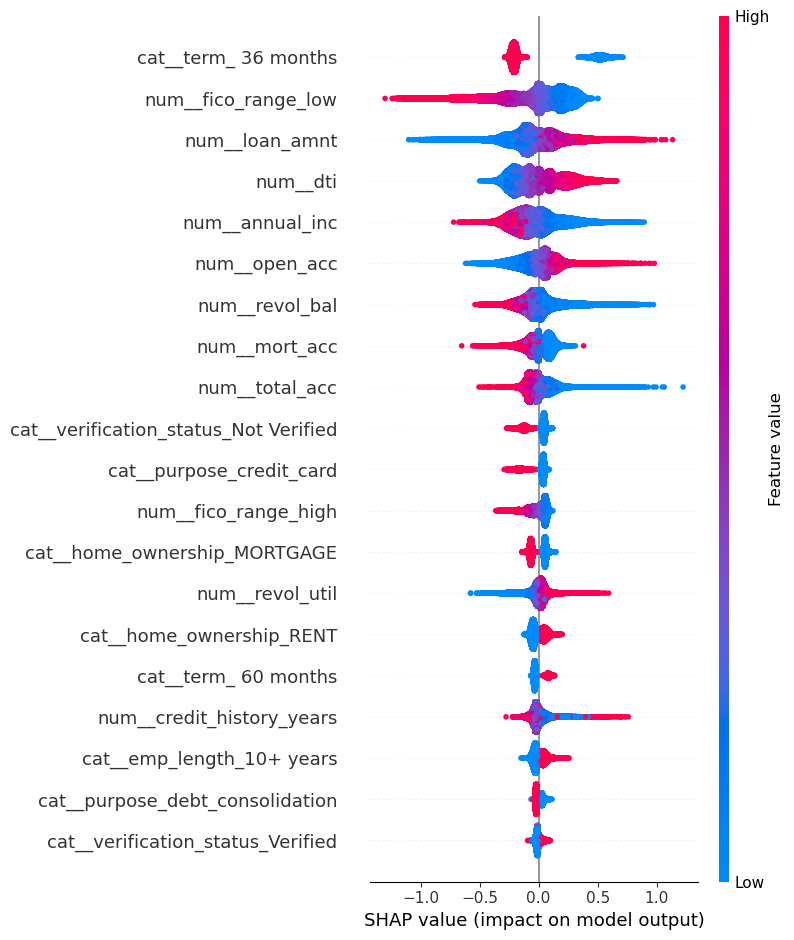

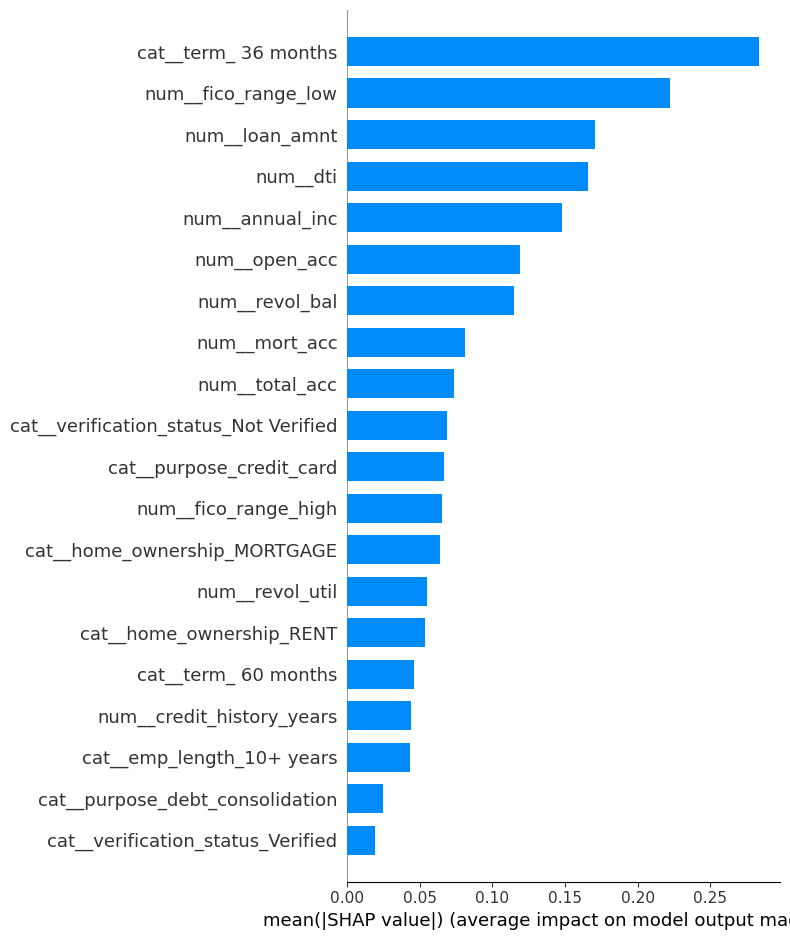

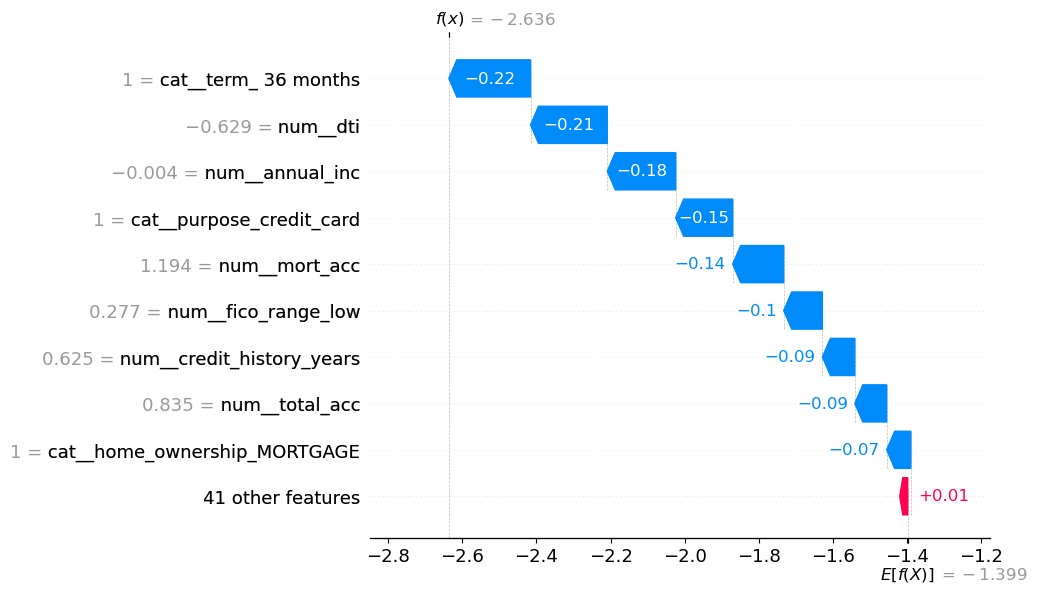

In [33]:
features=best_xgb_final.named_steps["preprocess"].get_feature_names_out()
shap.summary_plot(shap_values,X_test_transformed,feature_names=features)
shap.summary_plot(shap_values,X_test_transformed,feature_names=features,plot_type="bar")
shap.plots.waterfall(shap.Explanation(values=shap_values.values[0],
                                      base_values=shap_values.base_values[0],
                                      data=X_test_transformed[0],feature_names=features))

In [34]:
best_xgb_final.fit(X_small,Y)
joblib.dump(best_xgb_final,"../models/user_model.pkl")

['../models/user_model.pkl']

## Limitations

- Single Lending Platform
- Historical Dataset
- Economic Conditions can change arbitarily
- Model Uncertainty Remains
- Potential data drift (Economic conditions may change over time)

## Findings

- Credit related variables dominated risk prediction
- Borrower financial health matters
- Loan structure influences outcomes
- Tree based models provided a modest improvement over the linear baseline.
- Predictive signal exists beyond LendingClub risk grades
- Threshold selection creates business trade-offs